# EMPCA Component Check + Template Similarity

This notebook inspects EMPCA models trained in `wk3/train/train_empca_sum_channel.py`, plots PC1/PC2 comparisons, and quantifies PC1-template similarity in the same transformed domain (`ti_rfft`).

In [24]:
import pickle
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find repo root robustly from any notebook launch directory.
start = Path.cwd().resolve()
repo_root = None
for candidate in (start, *start.parents):
    if (candidate / 'wk3' / 'models').exists() and (candidate / 'reusable').exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate repo root containing wk3/models and reusable')

sys.path.insert(0, str(repo_root / 'reusable'))
from empca_TCY_optimized import ti_rfft, ti_irfft

models_dir = repo_root / 'wk3' / 'models'
print(f'repo_root: {repo_root}')
print(f'models_dir: {models_dir}')

repo_root: /home/dwong/DELight_mtr/PCA_dev
models_dir: /home/dwong/DELight_mtr/PCA_dev/wk3/models


In [25]:
model_paths = sorted(models_dir.glob('*.pkl'))
if not model_paths:
    raise FileNotFoundError(f'No .pkl files found under {models_dir}')

models = []
for model_path in model_paths:
    with open(model_path, 'rb') as f:
        payload = pickle.load(f)

    pca_model = payload['pca'] if isinstance(payload, dict) and 'pca' in payload else payload
    if hasattr(pca_model, 'eigvec'):
        comps = np.asarray(pca_model.eigvec)
    elif hasattr(pca_model, 'components_'):
        comps = np.asarray(pca_model.components_)
    else:
        raise AttributeError(f'No known component attribute in {model_path.name}')

    if comps.shape[0] < 2:
        raise RuntimeError(f'{model_path.name} has fewer than 2 components: {comps.shape}')

    comp1_raw = np.asarray(comps[0]).ravel()
    comp2_raw = np.asarray(comps[1]).ravel()

    # For plotting: convert near-real vectors to real; if still complex, use magnitude.
    comp1_plot = np.real_if_close(comp1_raw, tol=1000)
    comp2_plot = np.real_if_close(comp2_raw, tol=1000)
    if np.iscomplexobj(comp1_plot):
        comp1_plot = np.abs(comp1_plot)
    if np.iscomplexobj(comp2_plot):
        comp2_plot = np.abs(comp2_plot)

    weight_type = payload.get('weight_type', 'unknown') if isinstance(payload, dict) else 'unknown'
    noise_type = payload.get('noise_type', 'unknown') if isinstance(payload, dict) else 'unknown'

    model_row = {
        'name': model_path.name,
        'path': model_path,
        'payload': payload,
        'weight_type': weight_type,
        'noise_type': noise_type,
        'components_shape': tuple(comps.shape),
        'comp1_raw': comp1_raw,
        'comp2_raw': comp2_raw,
        'comp1_plot': np.asarray(comp1_plot, dtype=float),
        'comp2_plot': np.asarray(comp2_plot, dtype=float),
    }
    models.append(model_row)
    print(f"{model_row['name']}: components={model_row['components_shape']}, PC1={model_row['comp1_plot'].shape}, PC2={model_row['comp2_plot'].shape}")


PSD_run1_sum_mmc.pkl: components=(4, 16385), PC1=(16385,), PC2=(16385,)
PSD_run1_sum_pink.pkl: components=(4, 16385), PC1=(16385,), PC2=(16385,)
PSD_run1_sum_white.pkl: components=(4, 16385), PC1=(16385,), PC2=(16385,)
SNR2_run1_sum_mmc.pkl: components=(4, 16385), PC1=(16385,), PC2=(16385,)
SNR2_run1_sum_pink.pkl: components=(4, 16385), PC1=(16385,), PC2=(16385,)
SNR2_run1_sum_white.pkl: components=(4, 16385), PC1=(16385,), PC2=(16385,)


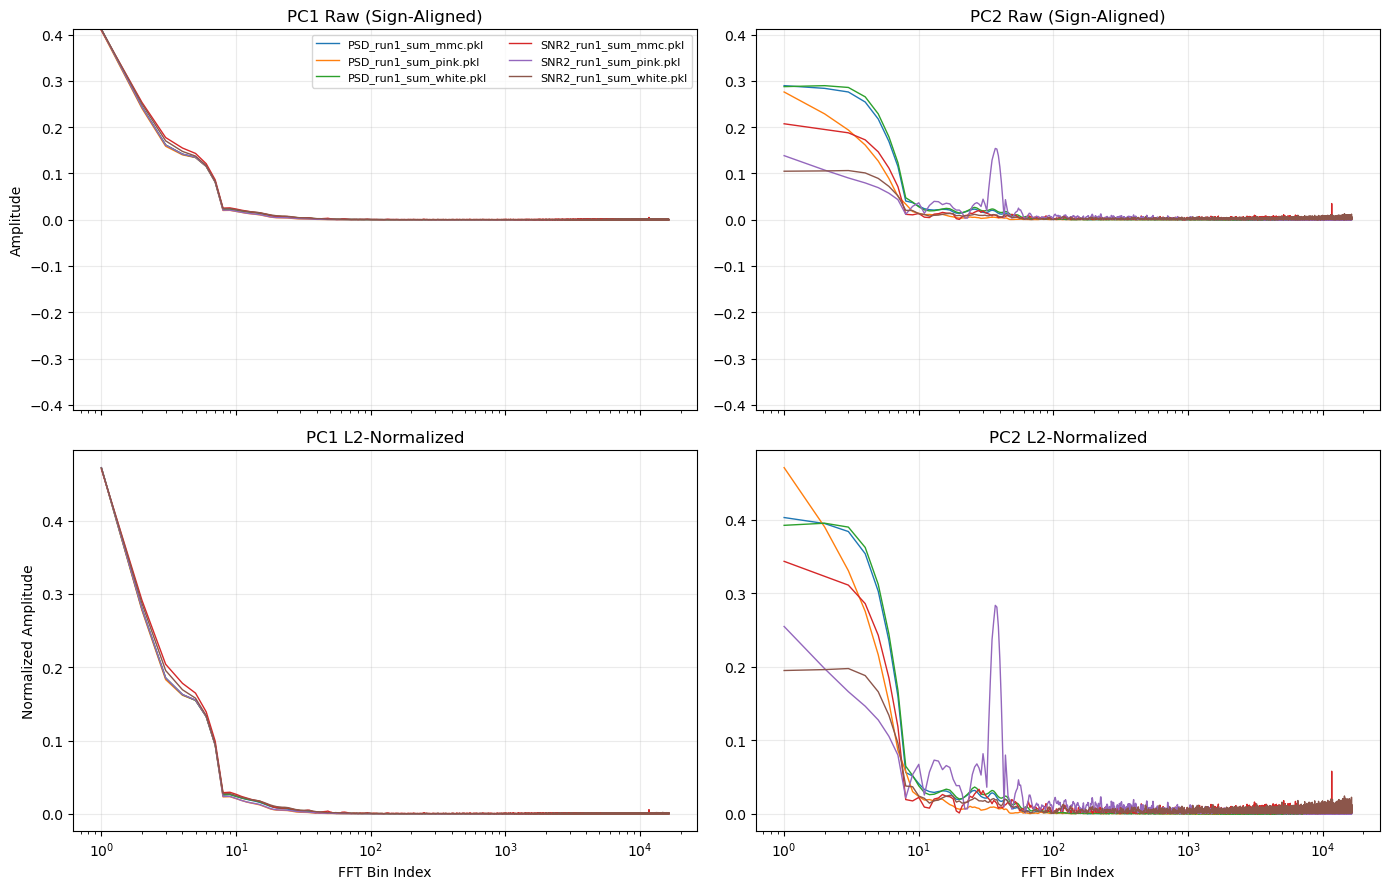

In [26]:
# Compare PC1 and PC2 overlays (shared y-scale)
fs_hz = None           # set to sampling rate (Hz) if known
use_log_x = True
use_log_y = False

if not models:
    raise RuntimeError('No models loaded. Run the previous cell first.')

ref1 = models[0]['comp1_plot']
ref2 = models[0]['comp2_plot']
aligned_pc1 = {}
aligned_pc2 = {}
for m in models:
    c1 = m['comp1_plot']
    c2 = m['comp2_plot']
    s1 = -1.0 if np.vdot(ref1, c1).real < 0 else 1.0
    s2 = -1.0 if np.vdot(ref2, c2).real < 0 else 1.0
    aligned_pc1[m['name']] = s1 * c1
    aligned_pc2[m['name']] = s2 * c2

n = len(ref1)
if fs_hz is None:
    x = np.arange(n, dtype=float)
    xlab = 'FFT Bin Index'
else:
    x = np.linspace(0.0, fs_hz / 2.0, n)
    xlab = 'Frequency (Hz)'

start_idx = 1 if use_log_x else 0
x_plot = x[start_idx:]

pc1_all = np.concatenate([v[start_idx:] for v in aligned_pc1.values()])
pc2_all = np.concatenate([v[start_idx:] for v in aligned_pc2.values()])
pc1_lim = np.max(np.abs(pc1_all))
pc2_lim = np.max(np.abs(pc2_all))
shared_lim = max(pc1_lim, pc2_lim)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex='col')
for name, comp in aligned_pc1.items():
    axes[0, 0].plot(x_plot, comp[start_idx:], label=name, linewidth=1.0)
for name, comp in aligned_pc2.items():
    axes[0, 1].plot(x_plot, comp[start_idx:], label=name, linewidth=1.0)

for name, comp in aligned_pc1.items():
    nrm = np.linalg.norm(comp)
    axes[1, 0].plot(x_plot, comp[start_idx:] / nrm if nrm > 0 else comp[start_idx:], linewidth=1.0)
for name, comp in aligned_pc2.items():
    nrm = np.linalg.norm(comp)
    axes[1, 1].plot(x_plot, comp[start_idx:] / nrm if nrm > 0 else comp[start_idx:], linewidth=1.0)

axes[0, 0].set_title('PC1 Raw (Sign-Aligned)')
axes[0, 1].set_title('PC2 Raw (Sign-Aligned)')
axes[1, 0].set_title('PC1 L2-Normalized')
axes[1, 1].set_title('PC2 L2-Normalized')
axes[0, 0].set_ylabel('Amplitude')
axes[1, 0].set_ylabel('Normalized Amplitude')
axes[1, 0].set_xlabel(xlab)
axes[1, 1].set_xlabel(xlab)

# Same y-scale for raw PC1 and PC2 panes
axes[0, 0].set_ylim(-shared_lim, shared_lim)
axes[0, 1].set_ylim(-shared_lim, shared_lim)

if use_log_x:
    for ax in (axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]):
        ax.set_xscale('log')
if use_log_y:
    for ax in (axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]):
        ax.set_yscale('symlog', linthresh=1e-12)

for ax in axes.ravel():
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

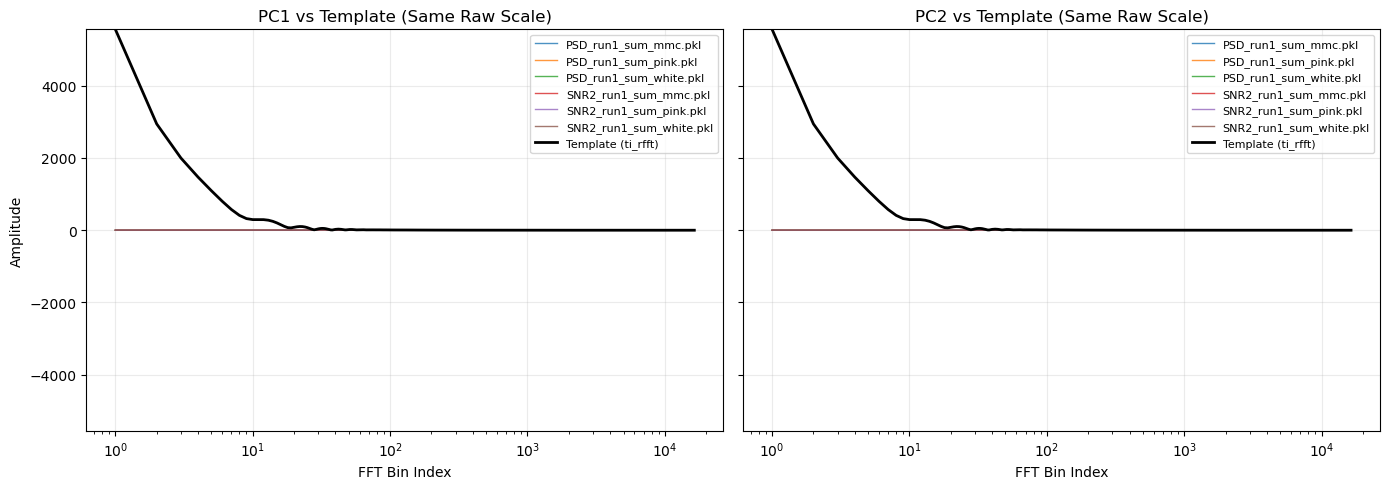

In [27]:
# Plot template on the same raw scale as components (for direct visual comparison)
# Uses your template: reusable/template/QP_template.npy

template_path = repo_root / 'reusable' / 'template' / 'QP_template.npy'
template_time = np.load(template_path).astype(np.float64)
template_freq = np.asarray(ti_rfft(template_time)).ravel()
template_plot = np.real_if_close(template_freq, tol=1000)
if np.iscomplexobj(template_plot):
    template_plot = np.abs(template_plot)
template_plot = np.asarray(template_plot, dtype=float)

if not models:
    raise RuntimeError('No models loaded. Run the model-loading cell first.')

# Build sign-aligned component dictionaries
ref1 = models[0]['comp1_plot']
ref2 = models[0]['comp2_plot']
aligned_pc1 = {}
aligned_pc2 = {}
for m in models:
    c1 = m['comp1_plot']
    c2 = m['comp2_plot']
    s1 = -1.0 if np.vdot(ref1, c1).real < 0 else 1.0
    s2 = -1.0 if np.vdot(ref2, c2).real < 0 else 1.0
    aligned_pc1[m['name']] = s1 * c1
    aligned_pc2[m['name']] = s2 * c2

# Also align template sign to the PC1 reference for easier comparison
s_t = -1.0 if np.vdot(ref1, template_plot).real < 0 else 1.0
template_aligned = s_t * template_plot

n = len(template_aligned)
fs_hz = None          # set to sampling rate if known
use_log_x = True
start_idx = 1 if use_log_x else 0

if fs_hz is None:
    x = np.arange(n, dtype=float)
    xlab = 'FFT Bin Index'
else:
    x = np.linspace(0.0, fs_hz / 2.0, n)
    xlab = 'Frequency (Hz)'
x_plot = x[start_idx:]

# Shared y-scale across PC1, PC2, and template (raw)
all_raw = [template_aligned[start_idx:]]
all_raw += [v[start_idx:] for v in aligned_pc1.values()]
all_raw += [v[start_idx:] for v in aligned_pc2.values()]
shared_lim = np.max(np.abs(np.concatenate(all_raw)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for name, comp in aligned_pc1.items():
    axes[0].plot(x_plot, comp[start_idx:], linewidth=1.0, alpha=0.8, label=name)
axes[0].plot(x_plot, template_aligned[start_idx:], color='k', linewidth=2.0, label='Template (ti_rfft)')
axes[0].set_title('PC1 vs Template (Same Raw Scale)')
axes[0].set_xlabel(xlab)
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-shared_lim, shared_lim)
axes[0].legend(fontsize=8, ncol=1)

for name, comp in aligned_pc2.items():
    axes[1].plot(x_plot, comp[start_idx:], linewidth=1.0, alpha=0.8, label=name)
axes[1].plot(x_plot, template_aligned[start_idx:], color='k', linewidth=2.0, label='Template (ti_rfft)')
axes[1].set_title('PC2 vs Template (Same Raw Scale)')
axes[1].set_xlabel(xlab)
axes[1].set_ylim(-shared_lim, shared_lim)
axes[1].legend(fontsize=8, ncol=1)

if use_log_x:
    axes[0].set_xscale('log')
    axes[1].set_xscale('log')

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Similarity Metrics: What They Mean

Before comparing, we align the sign of each PC1 to the template because PCA/EMPCA component sign is arbitrary (`v` and `-v` are equivalent).

### 1) Cosine Similarity

Formula:
`cosine(a,b) = (a·b) / (||a|| ||b||)`

Interpretation:
- `+1`: same shape and direction (very similar)
- `0`: no directional similarity
- `-1`: same shape but opposite sign (after sign alignment this usually becomes positive)

In this notebook, `abs_cosine` is used for ranking overall shape similarity.

### 2) Weighted Cosine Similarity

Formula:
`weighted_cosine(a,b,w) = sum(w*a*b) / sqrt(sum(w*a*a) * sum(w*b*b))`

Interpretation:
- Same scale as cosine (`-1` to `+1`), but bins with larger `w` contribute more.
- This is useful because training used weighted EMPCA (`1/PSD` or `SNR2`), so weighted cosine is closer to the model's optimization emphasis.

### 3) Normalized MSE (`norm_mse`)

We compare unit-norm vectors:
`mse = mean( (a/||a|| - b/||b||)^2 )`

Interpretation:
- `0`: identical normalized shape
- Larger values: larger average point-wise mismatch
- Lower is better

Use together with cosine:
- High `abs_cosine` + low `norm_mse` => strong match
- Similar cosine but higher `norm_mse` => broader/local mismatches still exist


In [28]:
# PC1 vs template similarity (same transform domain as training)
# Training uses ti_rfft on baseline-corrected traces, then weighted EMPCA.
# Use a template of matching time length (32768 samples here).
template_path = repo_root / 'reusable' / 'template' / 'QP_template.npy'
template_time = np.load(template_path).astype(np.float64)
template_freq = np.asarray(ti_rfft(template_time)).ravel()
template_plot = np.real_if_close(template_freq, tol=1000)
if np.iscomplexobj(template_plot):
    template_plot = np.abs(template_plot)
template_plot = np.asarray(template_plot, dtype=float)

def cosine_sim(a, b):
    aa = np.linalg.norm(a)
    bb = np.linalg.norm(b)
    if aa == 0 or bb == 0:
        return np.nan
    return float(np.dot(a, b) / (aa * bb))

def weighted_cosine(a, b, w):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    w = np.asarray(w, dtype=float)
    num = np.sum(w * a * b)
    den = np.sqrt(np.sum(w * a * a) * np.sum(w * b * b))
    if den == 0:
        return np.nan
    return float(num / den)

rows = []
for m in models:
    pc1 = m['comp1_plot'].copy()
    s = -1.0 if np.dot(pc1, template_plot) < 0 else 1.0
    pc1_aligned = s * pc1

    c = cosine_sim(pc1_aligned, template_plot)
    c_abs = abs(c) if np.isfinite(c) else np.nan

    payload = m['payload']
    w = None
    if isinstance(payload, dict):
        if m['weight_type'] == '1/PSD' and 'psd_eff' in payload:
            psd_eff = np.asarray(payload['psd_eff'], dtype=float)
            w = 1.0 / np.maximum(psd_eff, 1e-30)
        elif 'snr2_weight_path' in payload:
            wp = Path(payload['snr2_weight_path'])
            if not wp.is_absolute():
                wp = (repo_root / wp).resolve()
            if wp.exists():
                w = np.load(wp).astype(float)

    wc = weighted_cosine(pc1_aligned, template_plot, w) if w is not None else np.nan
    mse = float(np.mean((pc1_aligned / np.linalg.norm(pc1_aligned) - template_plot / np.linalg.norm(template_plot)) ** 2))

    rows.append({
        'model': m['name'],
        'weight_type': m['weight_type'],
        'noise_type': m['noise_type'],
        'cosine': c,
        'abs_cosine': c_abs,
        'weighted_cosine': wc,
        'norm_mse': mse,
        'pc1_aligned': pc1_aligned,
    })

sim_df = pd.DataFrame(rows).sort_values('abs_cosine', ascending=False).reset_index(drop=True)
sim_df[['model','weight_type','noise_type','cosine','abs_cosine','weighted_cosine','norm_mse']]

,model,weight_type,noise_type,cosine,abs_cosine,weighted_cosine,norm_mse
0,PSD_run1_sum_pink.pkl,1/PSD,pink,0.960471,0.960471,0.928491,0.000005
1,SNR2_run1_sum_pink.pkl,SNR2=|H|^2/PSD,pink,0.959651,0.959651,0.989236,0.000005
2,PSD_run1_sum_mmc.pkl,1/PSD,mmc,0.959519,0.959519,0.942701,0.000005
3,PSD_run1_sum_white.pkl,1/PSD,white,0.959357,0.959357,0.959357,0.000005
4,SNR2_run1_sum_white.pkl,SNR2=|H|^2/PSD,white,0.952958,0.952958,0.990440,0.000006
5,SNR2_run1_sum_mmc.pkl,SNR2=|H|^2/PSD,mmc,0.949498,0.949498,0.989430,0.000006


## How To Read The Difference Plots

- **Overlay panel**: shows where PC1 and template track each other.
- **Residual (`PC1_norm - Template_norm`)**:
  - Near `0` means strong local agreement.
  - Persistent positive/negative regions show systematic deviation.
- **Absolute residual (log-log)**:
  - Highlights bins where mismatch is largest.
  - Useful to see whether differences are concentrated in low-, mid-, or high-frequency bins.

Practical rule:
1. Rank by `abs_cosine` (global shape match).
2. Confirm with low `norm_mse` (pointwise match).
3. Inspect residual plots to localize where differences happen.


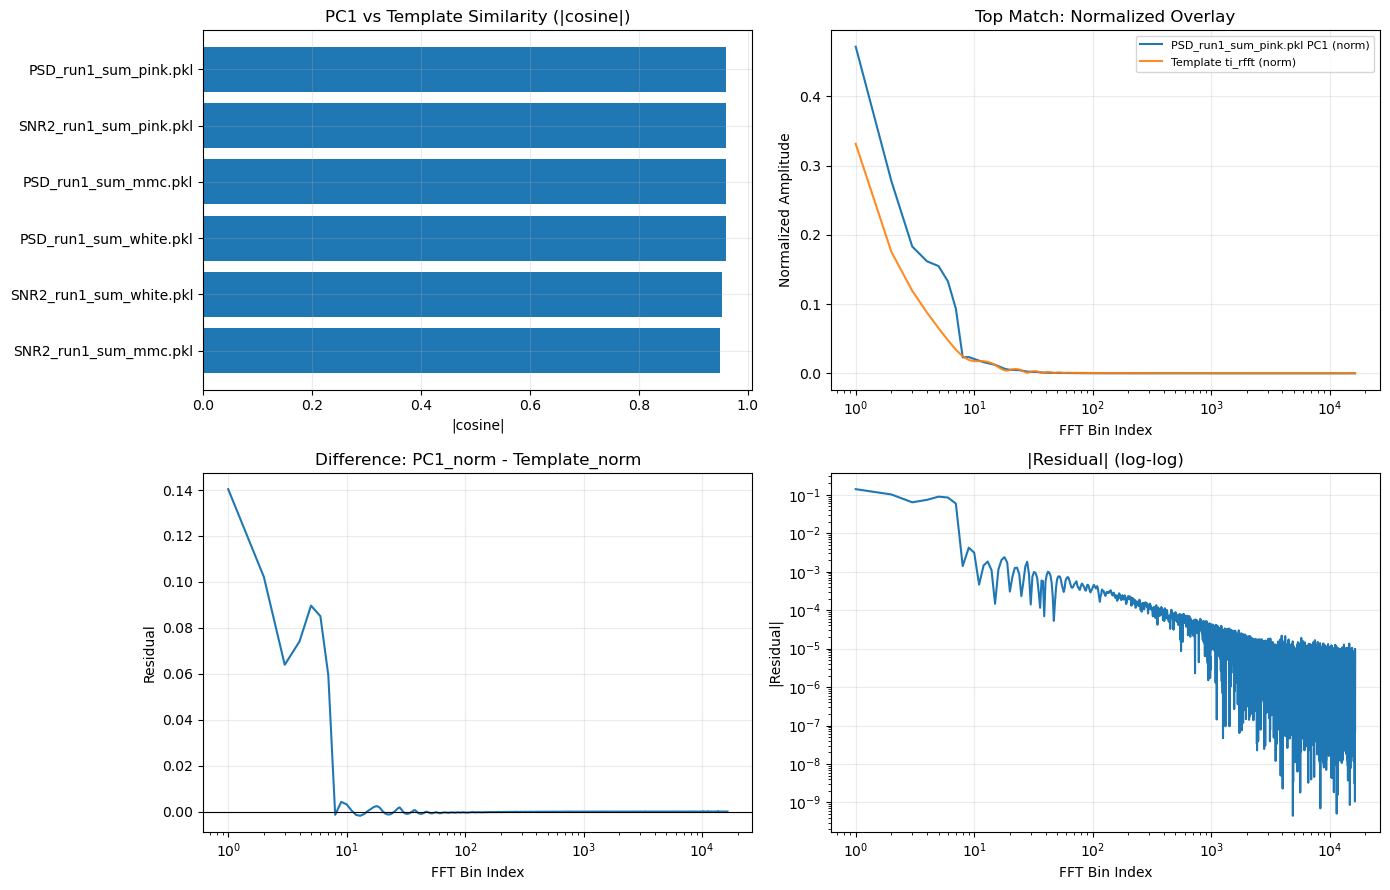

Top model: PSD_run1_sum_pink.pkl
cosine             0.960471
abs_cosine         0.960471
weighted_cosine    0.928491
norm_mse           0.000005
Name: 0, dtype: object


In [29]:
# Visualize similarity and differences for top model
top = sim_df.iloc[0]
top_model = top['model']
pc1 = top['pc1_aligned']
tmpl = template_plot

x = np.arange(len(pc1), dtype=float)
start_idx = 1 if True else 0
x_plot = x[start_idx:]
pc1n = pc1 / np.linalg.norm(pc1)
tmpln = tmpl / np.linalg.norm(tmpl)
resid = pc1n - tmpln

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Similarity ranking
axes[0, 0].barh(sim_df['model'], sim_df['abs_cosine'])
axes[0, 0].invert_yaxis()
axes[0, 0].set_title('PC1 vs Template Similarity (|cosine|)')
axes[0, 0].set_xlabel('|cosine|')

# 2) Overlay top PC1 and template
axes[0, 1].plot(x_plot, pc1n[start_idx:], label=f'{top_model} PC1 (norm)')
axes[0, 1].plot(x_plot, tmpln[start_idx:], label='Template ti_rfft (norm)', alpha=0.9)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Top Match: Normalized Overlay')
axes[0, 1].set_xlabel('FFT Bin Index')
axes[0, 1].set_ylabel('Normalized Amplitude')
axes[0, 1].legend(fontsize=8)

# 3) Residual curve
axes[1, 0].plot(x_plot, resid[start_idx:])
axes[1, 0].axhline(0.0, color='k', linewidth=0.8)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Difference: PC1_norm - Template_norm')
axes[1, 0].set_xlabel('FFT Bin Index')
axes[1, 0].set_ylabel('Residual')

# 4) Absolute residual emphasis
axes[1, 1].plot(x_plot, np.abs(resid[start_idx:]))
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('|Residual| (log-log)')
axes[1, 1].set_xlabel('FFT Bin Index')
axes[1, 1].set_ylabel('|Residual|')

for ax in axes.ravel():
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print('Top model:', top_model)
print(top[['cosine','abs_cosine','weighted_cosine','norm_mse']])

## EMPCA Component Interpretation Validation Protocol

Objective: validate dominant alignment and subspace equivalence (not strict equality):

- `u1` aligns with template-like mode
- `u2` aligns with time-derivative-like mode
- `u3` aligns with shape-variation-like mode

This section follows metric-based and subspace-based tests under the training metric.


In [30]:
import h5py

# Select one model artifact to validate in depth.
# Change this string to any model in wk3/models.
selected_model_name = 'PSD_run1_sum_mmc.pkl'

selected = [m for m in models if m['name'] == selected_model_name]
if not selected:
    raise ValueError(f'Model not found: {selected_model_name}')
selected = selected[0]
payload = selected['payload']

# Pull first 3 EMPCA components from the selected model (complex-valued vectors in ti_rfft space).
with open(selected['path'], 'rb') as f:
    artifact = pickle.load(f)

pca_model = artifact['pca'] if isinstance(artifact, dict) and 'pca' in artifact else artifact
if hasattr(pca_model, 'eigvec'):
    comps = np.asarray(pca_model.eigvec)
elif hasattr(pca_model, 'components_'):
    comps = np.asarray(pca_model.components_)
else:
    raise AttributeError('No recognized component attribute in selected model.')

if comps.shape[0] < 3:
    raise RuntimeError(f'Need at least 3 components; got {comps.shape}')

U = np.asarray(comps[:3], dtype=complex)  # shape: (3, n_freq)
n_freq = U.shape[1]

# Build weighting vector W exactly as training intended for this artifact.
if isinstance(artifact, dict) and artifact.get('weight_type') == '1/PSD' and 'psd_eff' in artifact:
    psd_eff = np.asarray(artifact['psd_eff'], dtype=float)
    W = 1.0 / np.maximum(psd_eff, 1e-30)
elif isinstance(artifact, dict) and 'snr2_weight_path' in artifact:
    wp = Path(artifact['snr2_weight_path'])
    if not wp.is_absolute():
        wp = (repo_root / wp).resolve()
    if not wp.exists():
        raise FileNotFoundError(f'SNR2 weight file not found: {wp}')
    W = np.asarray(np.load(wp), dtype=float)
else:
    raise RuntimeError('Could not determine training-consistent weights from artifact.')

if len(W) != n_freq:
    raise ValueError(f'Weight length mismatch: len(W)={len(W)} vs n_freq={n_freq}')

# Template and derivative references in the SAME transform domain as training (ti_rfft).
template_path = repo_root / 'reusable' / 'template' / 'QP_template.npy'
template_time = np.asarray(np.load(template_path), dtype=float)

if template_time.ndim != 1:
    raise ValueError(f'template_time must be 1D, got {template_time.shape}')

# fs_hz is only needed for derivative scaling; set if known. If unknown, use fs=1 for relative derivative mode.
fs_hz = 1.0
dt = 1.0 / fs_hz

template_dt_time = np.gradient(template_time, dt)

template_f = np.asarray(ti_rfft(template_time), dtype=complex).ravel()
template_dt_f = np.asarray(ti_rfft(template_dt_time), dtype=complex).ravel()

if len(template_f) != n_freq:
    raise ValueError(f'Template transform length mismatch: {len(template_f)} vs {n_freq}')

print('Selected model:', selected_model_name)
print('U shape (3, n_freq):', U.shape)
print('Weight type:', artifact.get('weight_type', 'unknown'))
print('Template path:', template_path)


Selected model: PSD_run1_sum_mmc.pkl
U shape (3, n_freq): (3, 16385)
Weight type: 1/PSD
Template path: /home/dwong/DELight_mtr/PCA_dev/reusable/template/QP_template.npy


In [31]:
# Weighted linear algebra helpers (complex-safe, no abs() in core metrics)

def weighted_inner(a, b, w):
    a = np.asarray(a, dtype=complex).ravel()
    b = np.asarray(b, dtype=complex).ravel()
    w = np.asarray(w, dtype=float).ravel()
    return np.sum(np.conj(a) * w * b)


def weighted_norm(a, w):
    v = np.real(weighted_inner(a, a, w))
    return np.sqrt(max(v, 0.0))


def weighted_normalize(a, w, eps=1e-30):
    n = weighted_norm(a, w)
    if n < eps:
        return np.asarray(a, dtype=complex)
    return np.asarray(a, dtype=complex) / n


def weighted_cosine(a, b, w):
    num = weighted_inner(a, b, w)
    den = weighted_norm(a, w) * weighted_norm(b, w)
    if den <= 0:
        return np.nan + 0j
    return num / den


def weighted_ls_solve(B, y, w, ridge=1e-18):
    # B: (n_freq, n_basis), y: (n_freq,), w: (n_freq,)
    Wb = w[:, None] * B
    G = B.conj().T @ Wb
    G = G + ridge * np.eye(G.shape[0], dtype=complex)
    rhs = B.conj().T @ (w * y)
    coeff = np.linalg.solve(G, rhs)
    return coeff


def project_weighted(B, y, w):
    c = weighted_ls_solve(B, y, w)
    yhat = B @ c
    return yhat, c


In [32]:
# Build shape reference from traces if available; otherwise use a clearly-labeled proxy.
# Protocol-preferred: shape mode from residual traces after removing template and derivative projections.

def load_training_traces_from_artifact(artifact_dict, max_traces=2000):
    if not isinstance(artifact_dict, dict):
        return None, 'artifact is not a dict'
    paths = artifact_dict.get('dataset_paths', None)
    trace_key = artifact_dict.get('trace_key', 'traces')
    if not paths:
        return None, 'dataset_paths missing'

    chunks = []
    loaded = 0
    for p in paths:
        fp = Path(p)
        if not fp.exists():
            continue
        with h5py.File(fp, 'r') as f:
            if trace_key not in f:
                continue
            arr = np.asarray(f[trace_key][:], dtype=float)
            # Expected shape in training: (N, 1, n_time)
            if arr.ndim == 3:
                arr = arr[:, 0, :]
            elif arr.ndim != 2:
                continue
            remain = max_traces - loaded
            if remain <= 0:
                break
            take = min(remain, arr.shape[0])
            chunks.append(arr[:take])
            loaded += take
            if loaded >= max_traces:
                break

    if not chunks:
        return None, 'no readable local dataset_paths for this artifact'

    X = np.concatenate(chunks, axis=0)
    return X, None


def baseline_correct(X, pretrigger=4000, method='mean'):
    X = np.asarray(X, dtype=float)
    pre = X[:, :pretrigger]
    if method == 'median':
        b = np.median(pre, axis=1)
    else:
        b = np.mean(pre, axis=1)
    return X - b[:, None]


# Preferred shape mode estimation
shape_mode_source = None
X_time, load_err = load_training_traces_from_artifact(artifact, max_traces=2000)

if X_time is not None:
    cfg = artifact.get('cfg', {}) if isinstance(artifact, dict) else {}
    pretrigger = int(cfg.get('pretrigger', 4000))
    baseline_method = cfg.get('baseline_method', 'mean')

    X0 = baseline_correct(X_time, pretrigger=pretrigger, method=baseline_method)
    Xf = np.asarray(ti_rfft(X0), dtype=complex)  # (n_traces, n_freq)

    # Remove template + derivative from each trace via weighted LS.
    B2 = np.column_stack([
        weighted_normalize(template_f, W),
        weighted_normalize(template_dt_f, W),
    ])

    X_res = np.empty_like(Xf)
    for i in range(Xf.shape[0]):
        xhat, _ = project_weighted(B2, Xf[i], W)
        X_res[i] = Xf[i] - xhat

    # First PCA mode of residuals via SVD in complex space.
    X_res_centered = X_res - np.mean(X_res, axis=0, keepdims=True)
    _, _, Vh = np.linalg.svd(X_res_centered, full_matrices=False)
    shape_mode_f = np.asarray(Vh[0], dtype=complex)
    shape_mode_source = f'from residual traces (n={Xf.shape[0]})'
else:
    # Fallback proxy: remove template+derivative from u3 itself.
    # This is NOT independent evidence, only a proxy when traces are unavailable.
    B2 = np.column_stack([
        weighted_normalize(template_f, W),
        weighted_normalize(template_dt_f, W),
    ])
    u3 = U[2]
    u3_proj, _ = project_weighted(B2, u3, W)
    shape_mode_f = u3 - u3_proj
    shape_mode_source = f'proxy from u3 residual (trace data unavailable: {load_err})'

# Assemble weighted-normalized reference basis R.
r_template = weighted_normalize(template_f, W)
r_deriv = weighted_normalize(template_dt_f, W)
r_shape = weighted_normalize(shape_mode_f, W)
R = np.vstack([r_template, r_deriv, r_shape])

# Weighted-normalize U for metric comparability.
U_norm = np.vstack([weighted_normalize(U[i], W) for i in range(3)])

print('Shape mode source:', shape_mode_source)
print('R shape:', R.shape)


Shape mode source: from residual traces (n=1000)
R shape: (3, 16385)


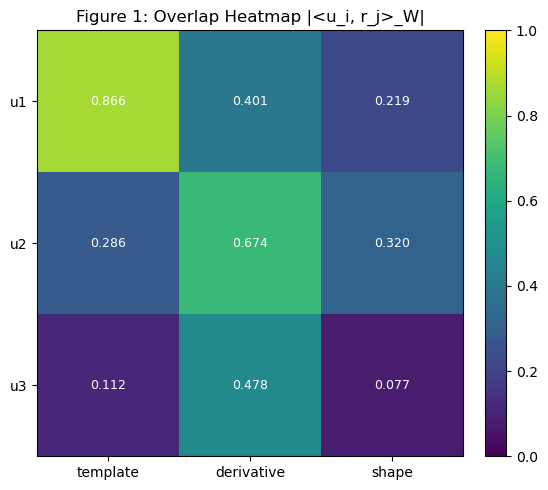

array([[0.86588308, 0.40098394, 0.21921377],
       [0.28581714, 0.67411216, 0.31977741],
       [0.11179851, 0.47763756, 0.07669082]])

In [33]:
# Figure 1: Overlap matrix heatmap  M[i,j] = |<u_i, r_j>_W|
labels_u = ['u1', 'u2', 'u3']
labels_r = ['template', 'derivative', 'shape']

M = np.zeros((3, 3), dtype=float)
for i in range(3):
    for j in range(3):
        M[i, j] = np.abs(weighted_inner(U_norm[i], R[j], W))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M, cmap='viridis', vmin=0.0, vmax=1.0)
ax.set_xticks(np.arange(3), labels=labels_r)
ax.set_yticks(np.arange(3), labels=labels_u)
ax.set_title('Figure 1: Overlap Heatmap |<u_i, r_j>_W|')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{M[i,j]:.3f}', ha='center', va='center', color='w', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

M


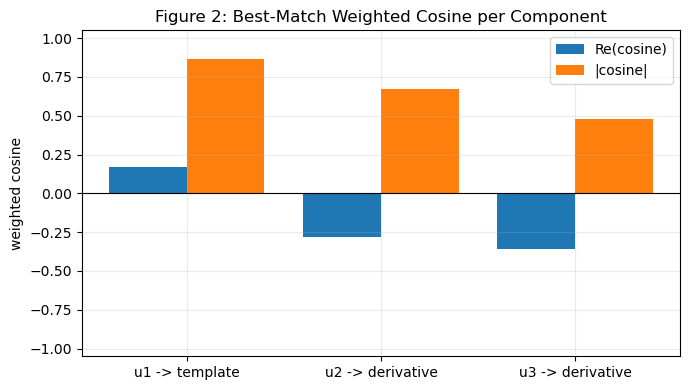

Best matches:
  u1 -> template : cosine=0.1686+0.8493j, |cos|=0.8659
  u2 -> derivative : cosine=-0.2842+0.6113j, |cos|=0.6741
  u3 -> derivative : cosine=-0.3603-0.3135j, |cos|=0.4776


In [34]:
# Figure 2: Best match per component using weighted cosine
# Keep complex phase in metric; visualize real part + magnitude.
C = np.zeros((3, 3), dtype=complex)
for i in range(3):
    for j in range(3):
        C[i, j] = weighted_cosine(U_norm[i], R[j], W)

best_j = np.argmax(np.abs(C), axis=1)
best_labels = [labels_r[j] for j in best_j]
best_vals = C[np.arange(3), best_j]

x = np.arange(3)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, np.real(best_vals), width=0.4, label='Re(cosine)')
ax.bar(x + 0.2, np.abs(best_vals), width=0.4, label='|cosine|')
ax.set_xticks(x, [f'{labels_u[i]} -> {best_labels[i]}' for i in range(3)])
ax.set_ylim(-1.05, 1.05)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_title('Figure 2: Best-Match Weighted Cosine per Component')
ax.set_ylabel('weighted cosine')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Best matches:')
for i in range(3):
    print(f'  {labels_u[i]} -> {best_labels[i]} : cosine={best_vals[i]:.4f}, |cos|={abs(best_vals[i]):.4f}')


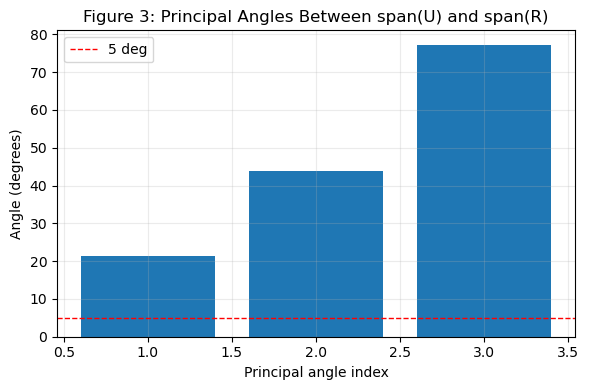

Principal angles (deg): [21.2561 43.7411 77.2092]


In [35]:
# Figure 3: Subspace equivalence via principal angles
# Weighted subspaces: sqrt(W)*U and sqrt(W)*R
sqrtW = np.sqrt(W)
Uw = (sqrtW[None, :] * U_norm).T   # (n_freq, 3)
Rw = (sqrtW[None, :] * R).T        # (n_freq, 3)

Q_U, _ = np.linalg.qr(Uw)
Q_R, _ = np.linalg.qr(Rw)

S = np.linalg.svd(Q_U.conj().T @ Q_R, compute_uv=False)
S = np.clip(np.real(S), -1.0, 1.0)
angles_deg = np.degrees(np.arccos(S))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(np.arange(1, len(angles_deg)+1), angles_deg)
ax.axhline(5.0, color='r', linestyle='--', linewidth=1.0, label='5 deg')
ax.set_xlabel('Principal angle index')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Figure 3: Principal Angles Between span(U) and span(R)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Principal angles (deg):', np.round(angles_deg, 4))


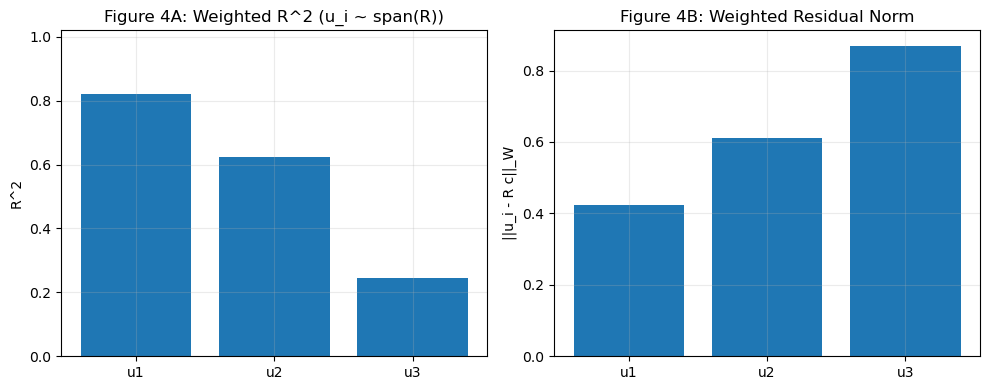

u1: R^2=0.820212, residual_norm=0.424015
u2: R^2=0.625077, residual_norm=0.612309
u3: R^2=0.244703, residual_norm=0.869078


In [36]:
# Figure 4: Regression test (u_i reconstructed by R)
# For each u_i, solve weighted LS: u_i ≈ R^T c
B_R = R.T  # (n_freq, 3)

r2_list = []
resid_list = []
for i in range(3):
    y = U_norm[i]
    yhat, c = project_weighted(B_R, y, W)
    err = y - yhat
    sse = np.real(weighted_inner(err, err, W))
    sst = np.real(weighted_inner(y, y, W))
    r2 = 1.0 - sse / max(sst, 1e-30)
    r2_list.append(r2)
    resid_list.append(np.sqrt(max(sse, 0.0)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels_u, r2_list)
axes[0].set_ylim(0, 1.02)
axes[0].set_title('Figure 4A: Weighted R^2 (u_i ~ span(R))')
axes[0].set_ylabel('R^2')
axes[0].grid(alpha=0.25)

axes[1].bar(labels_u, resid_list)
axes[1].set_title('Figure 4B: Weighted Residual Norm')
axes[1].set_ylabel('||u_i - R c||_W')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

for i in range(3):
    print(f'{labels_u[i]}: R^2={r2_list[i]:.6f}, residual_norm={resid_list[i]:.6g}')


/tmp/ipykernel_1276636/1229705674.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([err_u, err_r], labels=['Model A: U basis', 'Model B: Ref basis'])


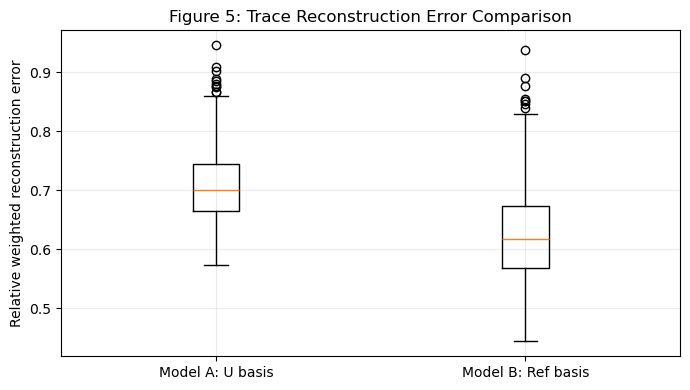

Median relative error (U basis): 0.7005313943525759
Median relative error (Ref basis): 0.6173415012239614


In [37]:
# Figure 5: Trace reconstruction comparison (if traces are available)
# Model A: x ≈ sum c_i u_i, using U basis
# Model B: x ≈ a*template + b*derivative + c*shape, using R basis

if X_time is None:
    print('Figure 5 skipped: trace data not available locally for this model.')
else:
    B_U = U_norm.T  # (n_freq, 3)
    B_R = R.T       # (n_freq, 3)

    # Recompute Xf to ensure this cell is self-contained with current X_time.
    cfg = artifact.get('cfg', {}) if isinstance(artifact, dict) else {}
    pretrigger = int(cfg.get('pretrigger', 4000))
    baseline_method = cfg.get('baseline_method', 'mean')
    X0 = baseline_correct(X_time, pretrigger=pretrigger, method=baseline_method)
    Xf_eval = np.asarray(ti_rfft(X0), dtype=complex)

    err_u = []
    err_r = []
    for i in range(Xf_eval.shape[0]):
        x = Xf_eval[i]

        xhat_u, _ = project_weighted(B_U, x, W)
        xhat_r, _ = project_weighted(B_R, x, W)

        e_u = np.real(weighted_inner(x - xhat_u, x - xhat_u, W)) / max(np.real(weighted_inner(x, x, W)), 1e-30)
        e_r = np.real(weighted_inner(x - xhat_r, x - xhat_r, W)) / max(np.real(weighted_inner(x, x, W)), 1e-30)
        err_u.append(e_u)
        err_r.append(e_r)

    err_u = np.asarray(err_u)
    err_r = np.asarray(err_r)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot([err_u, err_r], labels=['Model A: U basis', 'Model B: Ref basis'])
    ax.set_ylabel('Relative weighted reconstruction error')
    ax.set_title('Figure 5: Trace Reconstruction Error Comparison')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print('Median relative error (U basis):', np.median(err_u))
    print('Median relative error (Ref basis):', np.median(err_r))


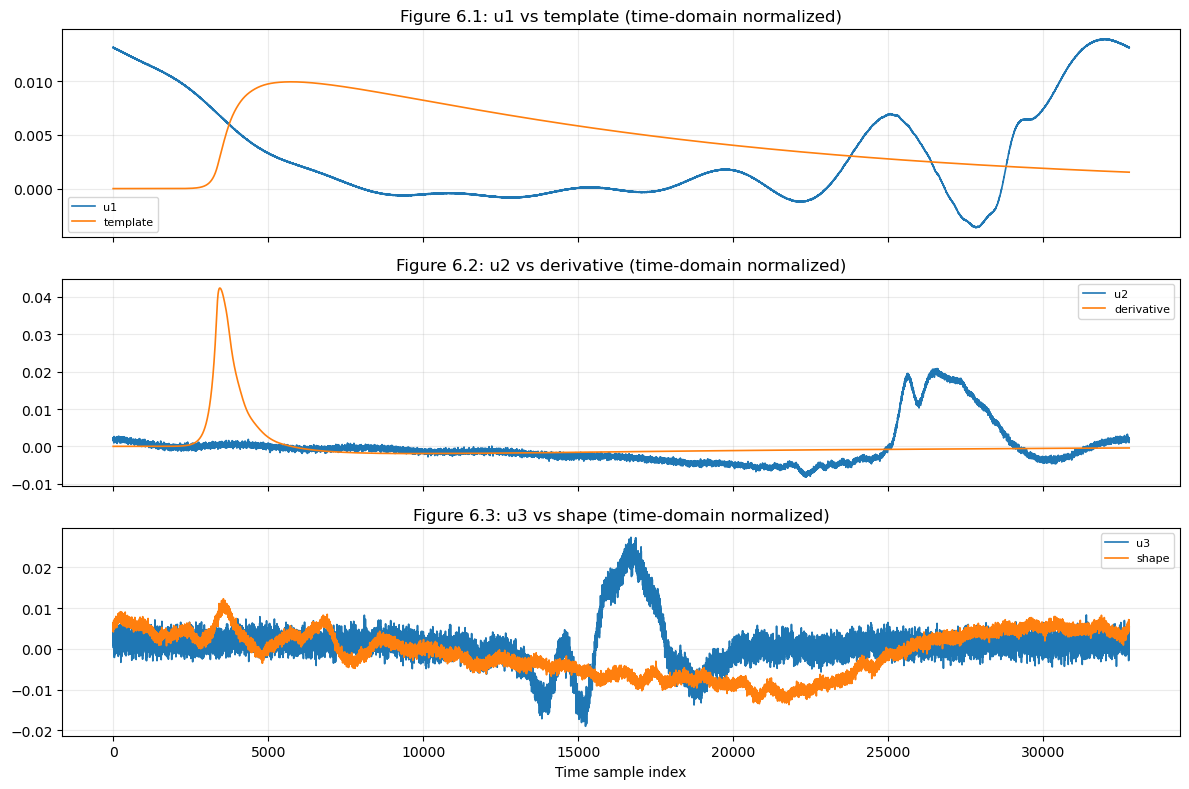

In [38]:
# Figure 6: Time-domain visualization using ti_irfft (not strict equality test)
# Compare u1/u2/u3 with template/derivative/shape references in time domain.

u_time = [np.asarray(ti_irfft(U_norm[i]), dtype=float).ravel() for i in range(3)]
r_time = [np.asarray(ti_irfft(R[i]), dtype=float).ravel() for i in range(3)]

names_left = ['u1', 'u2', 'u3']
names_right = ['template', 'derivative', 'shape']

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i in range(3):
    ul = u_time[i]
    rl = r_time[i]
    # Normalize in time-domain only for visual scale comparison.
    un = ul / (np.linalg.norm(ul) + 1e-30)
    rn = rl / (np.linalg.norm(rl) + 1e-30)

    # Align sign for display only.
    s = -1.0 if np.dot(un, rn) < 0 else 1.0
    un = s * un

    axes[i].plot(un, label=names_left[i], linewidth=1.2)
    axes[i].plot(rn, label=names_right[i], linewidth=1.2)
    axes[i].set_title(f'Figure 6.{i+1}: {names_left[i]} vs {names_right[i]} (time-domain normalized)')
    axes[i].grid(alpha=0.25)
    axes[i].legend(fontsize=8)

axes[-1].set_xlabel('Time sample index')
plt.tight_layout()
plt.show()


## Conclusion Guidance (Do Not Claim Strict Equality)

Use these outputs together:

- Strong `|cosine|` and high overlap on expected pairs support dominant alignment.
- Small principal angles support subspace equivalence between `span(U)` and `span(R)`.
- High regression `R^2` supports that EMPCA components are well explained by the reference basis.
- Trace reconstruction parity supports practical equivalence for representation quality.

Conclusion style:

`EMPCA components show dominant alignment and subspace equivalence to template/timing/shape modes under the training metric, without asserting strict component-wise equality.`
